In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.tree import export_text, plot_tree
from sklearn.model_selection import KFold, cross_validate, cross_val_score, train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, recall_score, precision_score,
                             f1_score, mean_squared_error)
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 13
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style("whitegrid")

print("✅ All libraries loaded successfully!")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Sklearn loaded")

✅ All libraries loaded successfully!
NumPy: 2.0.2
Pandas: 2.2.2
Sklearn loaded


In [3]:
np.random.seed(42)
n = 10000

# Generate features
data = {
    'days_since_last_login': np.random.exponential(scale=10, size=n).astype(int).clip(0, 60),
    'num_playlists': np.random.poisson(lam=8, size=n).clip(0, 50),
    'avg_daily_minutes': np.random.normal(loc=45, scale=20, size=n).clip(0, 180).round(1),
    'subscription_plan': np.random.choice(['Free', 'Premium', 'Family'], size=n, p=[0.4, 0.4, 0.2]),
    'device_type': np.random.choice(['Mobile', 'Desktop', 'Smart_Speaker'], size=n, p=[0.6, 0.3, 0.1]),
}

df_spotify = pd.DataFrame(data)

# Generate target: churn is more likely if inactive, few playlists, free plan
churn_prob = (
    0.05
    + 0.4 * (df_spotify['days_since_last_login'] > 14).astype(float)
    + 0.15 * (df_spotify['num_playlists'] < 3).astype(float)
    + 0.15 * (df_spotify['subscription_plan'] == 'Free').astype(float)
    - 0.1 * (df_spotify['avg_daily_minutes'] > 60).astype(float)
)
churn_prob = churn_prob.clip(0.02, 0.95)
df_spotify['churned'] = (np.random.random(n) < churn_prob).astype(int)

print("=" * 50)
print("SPOTIFY CHURN DATASET")
print("=" * 50)
print(f"Total users: {len(df_spotify):,}")
print(f"Stayed:      {(df_spotify['churned']==0).sum():,} ({(df_spotify['churned']==0).mean()*100:.1f}%)")
print(f"Churned:     {(df_spotify['churned']==1).sum():,} ({(df_spotify['churned']==1).mean()*100:.1f}%)")
print()
df_spotify

SPOTIFY CHURN DATASET
Total users: 10,000
Stayed:      8,153 (81.5%)
Churned:     1,847 (18.5%)



,days_since_last_login,num_playlists,avg_daily_minutes,subscription_plan,device_type,churned
0,4,6,55.4,Free,Desktop,0
1,30,9,35.7,Premium,Mobile,0
2,13,4,38.1,Premium,Desktop,0
3,9,7,20.1,Premium,Desktop,0
4,1,7,36.7,Premium,Mobile,0
...,...,...,...,...,...,...
9995,19,6,31.5,Free,Desktop,1
9996,22,6,20.7,Premium,Desktop,0
9997,29,9,33.2,Premium,Desktop,0
9998,5,9,40.5,Premium,Desktop,0


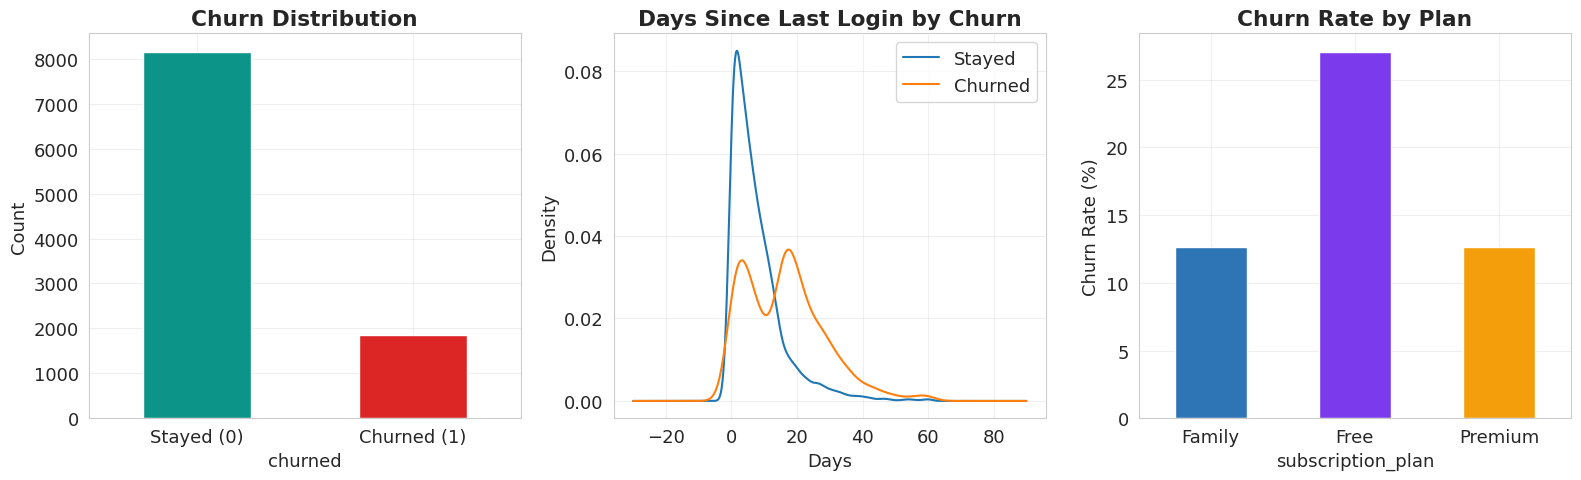

In [4]:
# ============================================
# CLASS DISTRIBUTION
# ============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Churn distribution
colors = ['#0D9488', '#DC2626']
df_spotify['churned'].value_counts().plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Count')

# Days since last login by churn
df_spotify.groupby('churned')['days_since_last_login'].plot(kind='kde', ax=axes[1])
axes[1].set_title('Days Since Last Login by Churn', fontweight='bold')
axes[1].legend(['Stayed', 'Churned'])
axes[1].set_xlabel('Days')

# Churn rate by subscription plan
churn_by_plan = df_spotify.groupby('subscription_plan')['churned'].mean() * 100
churn_by_plan.plot(kind='bar', ax=axes[2], color=['#2E75B6', '#7C3AED', '#F59E0B'])
axes[2].set_title('Churn Rate by Plan', fontweight='bold')
axes[2].set_ylabel('Churn Rate (%)')
axes[2].set_xticklabels(churn_by_plan.index, rotation=0)

plt.tight_layout()
plt.show()



In [5]:
# ============================================
# ENTROPY CALCULATION — FROM SCRATCH
# ============================================
# 🎤 "Let's compute entropy for our root node step by step"

def entropy(y):
    """Calculate entropy of a target array"""
    n = len(y)
    if n == 0:
        return 0
    counts = np.bincount(y)
    probs = counts[counts > 0] / n  # Remove zero-count classes
    return -np.sum(probs * np.log2(probs))

# Root node entropy
y = df_spotify['churned'].values
p_stayed = (y == 0).mean()
p_churned = (y == 1).mean()

print("=" * 50)
print("ROOT NODE ENTROPY CALCULATION")
print("=" * 50)
print(f"P(stayed)  = {(y==0).sum()}/{len(y)} = {p_stayed:.4f}")
print(f"P(churned) = {(y==1).sum()}/{len(y)} = {p_churned:.4f}")
print()
print(f"H(root) = -[{p_stayed:.4f} × log₂({p_stayed:.4f}) + {p_churned:.4f} × log₂({p_churned:.4f})]")
print(f"        = -[{p_stayed:.4f} × ({np.log2(p_stayed):.4f}) + {p_churned:.4f} × ({np.log2(p_churned):.4f})]")
print(f"        = -[{p_stayed * np.log2(p_stayed):.4f} + {p_churned * np.log2(p_churned):.4f}]")
print(f"        = {entropy(y):.4f}")
print()
print(f"💡 Max entropy for binary = 1.0 (at 50-50 split)")
print(f"   Our root node entropy  = {entropy(y):.4f}")
print(f"   → Node is {'fairly impure' if entropy(y) > 0.7 else 'somewhat impure'}")


ROOT NODE ENTROPY CALCULATION
P(stayed)  = 8153/10000 = 0.8153
P(churned) = 1847/10000 = 0.1847

H(root) = -[0.8153 × log₂(0.8153) + 0.1847 × log₂(0.1847)]
        = -[0.8153 × (-0.2946) + 0.1847 × (-2.4367)]
        = -[-0.2402 + -0.4501]
        = 0.6903

💡 Max entropy for binary = 1.0 (at 50-50 split)
   Our root node entropy  = 0.6903
   → Node is somewhat impure


In [7]:
# ============================================
# GINI IMPURITY — FROM SCRATCH
# ============================================


def gini_impurity(y):
    """Calculate Gini impurity of a target array"""
    n = len(y)
    if n == 0:
        return 0
    counts = np.bincount(y)
    probs = counts[counts > 0] / n
    return 1 - np.sum(probs ** 2)

print("=" * 50)
print("GINI IMPURITY CALCULATION")
print("=" * 50)
print(f"GI = 1 - [P(stayed)² + P(churned)²]")
print(f"   = 1 - [{p_stayed:.4f}² + {p_churned:.4f}²]")
print(f"   = 1 - [{p_stayed**2:.4f} + {p_churned**2:.4f}]")
print(f"   = 1 - {p_stayed**2 + p_churned**2:.4f}")
print(f"   = {gini_impurity(y):.4f}")
print()
print("COMPARISON:")
print(f"  Entropy: {entropy(y):.4f}  (max = 1.0 for binary)")
print(f"  Gini:    {gini_impurity(y):.4f}  (max = 0.5 for binary)")
print(f"  → Same concept, different scale")
print(f"  → Gini is faster (no log), sklearn default")


GINI IMPURITY CALCULATION
GI = 1 - [P(stayed)² + P(churned)²]
   = 1 - [0.8153² + 0.1847²]
   = 1 - [0.6647 + 0.0341]
   = 1 - 0.6988
   = 0.3012

COMPARISON:
  Entropy: 0.6903  (max = 1.0 for binary)
  Gini:    0.3012  (max = 0.5 for binary)
  → Same concept, different scale
  → Gini is faster (no log), sklearn default


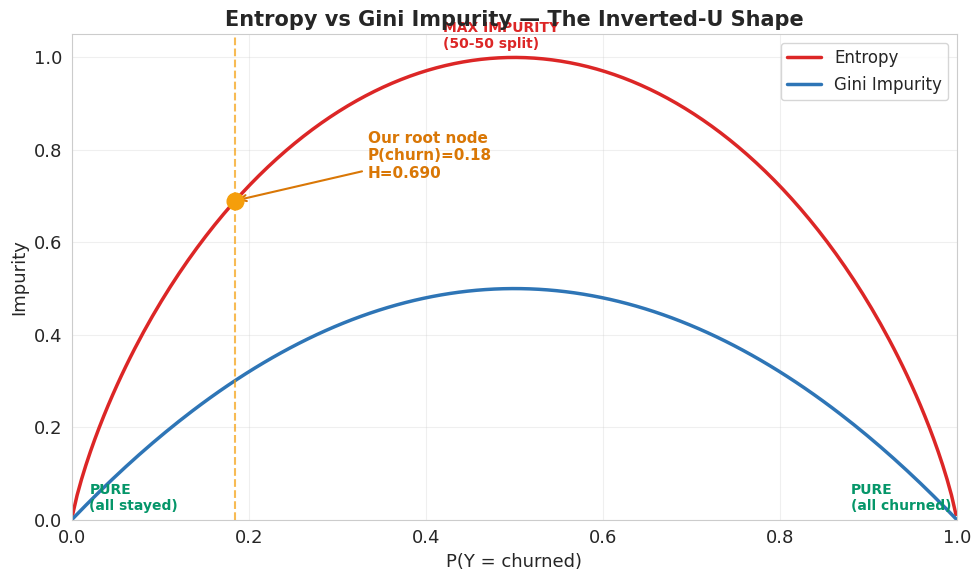

In [8]:
# ============================================
# ENTROPY CURVE PLOT
# ============================================

p_range = np.linspace(0.001, 0.999, 200)
entropy_vals = -p_range * np.log2(p_range) - (1-p_range) * np.log2(1-p_range)
gini_vals = 2 * p_range * (1-p_range)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(p_range, entropy_vals, color='#DC2626', linewidth=2.5, label='Entropy')
ax.plot(p_range, gini_vals, color='#2E75B6', linewidth=2.5, label='Gini Impurity')

# Mark our Spotify root node
ax.axvline(x=p_churned, color='#F59E0B', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(p_churned, entropy(y), 'o', color='#F59E0B', markersize=12, zorder=5)
ax.annotate(f'Our root node\nP(churn)={p_churned:.2f}\nH={entropy(y):.3f}',
            xy=(p_churned, entropy(y)), xytext=(p_churned+0.15, entropy(y)+0.05),
            fontsize=11, fontweight='bold', color='#D97706',
            arrowprops=dict(arrowstyle='->', color='#D97706', lw=1.5))

ax.set_xlabel('P(Y = churned)', fontsize=13)
ax.set_ylabel('Impurity', fontsize=13)
ax.set_title('Entropy vs Gini Impurity — The Inverted-U Shape', fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

# Annotations
ax.annotate('PURE\n(all stayed)', xy=(0.02, 0.02), fontsize=10, color='#059669', fontweight='bold')
ax.annotate('PURE\n(all churned)', xy=(0.88, 0.02), fontsize=10, color='#059669', fontweight='bold')
ax.annotate('MAX IMPURITY\n(50-50 split)', xy=(0.42, 1.02), fontsize=10, color='#DC2626', fontweight='bold')

plt.tight_layout()
plt.show()



INFORMATION GAIN — COMPARING CANDIDATE SPLITS

Parent Entropy: H(root) = 0.6903
────────────────────────────────────────────────────────────

📊 SPLIT 1: days_since_last_login > 14
   Left  (active, ≤14 days):  7,839 users, H = 0.4658
   Right (inactive, >14 days): 2,161 users, H = 0.9999
   Weighted H(children) = (7839/10000)×0.4658 + (2161/10000)×0.9999 = 0.5812
   IG = 0.6903 - 0.5812 = 0.1090

📊 SPLIT 2: subscription_plan == 'Free'
   Left  (Premium/Family): 5,957 users, H = 0.5475
   Right (Free):           4,043 users, H = 0.8423
   Weighted H(children) = 0.6667
   IG = 0.6903 - 0.6667 = 0.0236

📊 SPLIT 3: num_playlists < 3
   Left  (≥3 playlists): 9,863 users, H = 0.6833
   Right (<3 playlists): 137 users, H = 0.9796
   Weighted H(children) = 0.6874
   IG = 0.6903 - 0.6874 = 0.0029

🏆 WINNER: days_since_last_login > 14 (IG = 0.1090)
   → Tree picks this as the ROOT SPLIT!


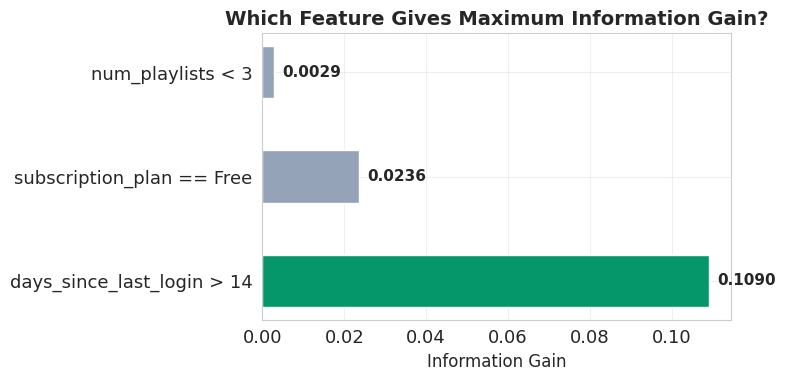

In [9]:
# ============================================
# INFORMATION GAIN — COMPARING TWO SPLITS
# ============================================


def weighted_entropy(y_left, y_right):
    """Weighted average entropy of two child nodes"""
    n = len(y_left) + len(y_right)
    return (len(y_left)/n) * entropy(y_left) + (len(y_right)/n) * entropy(y_right)

def information_gain(y_parent, y_left, y_right):
    """IG = parent entropy - weighted child entropy"""
    return entropy(y_parent) - weighted_entropy(y_left, y_right)

y = df_spotify['churned'].values

# SPLIT 1: days_since_last_login > 14
mask1 = df_spotify['days_since_last_login'] > 14
y_left1 = y[~mask1]  # active users (<=14 days)
y_right1 = y[mask1]   # inactive users (>14 days)
ig1 = information_gain(y, y_left1, y_right1)

# SPLIT 2: subscription_plan == 'Free'
mask2 = df_spotify['subscription_plan'] == 'Free'
y_left2 = y[~mask2]  # Premium/Family
y_right2 = y[mask2]   # Free
ig2 = information_gain(y, y_left2, y_right2)

# SPLIT 3: num_playlists < 3
mask3 = df_spotify['num_playlists'] < 3
y_left3 = y[~mask3]
y_right3 = y[mask3]
ig3 = information_gain(y, y_left3, y_right3)

print("=" * 60)
print("INFORMATION GAIN — COMPARING CANDIDATE SPLITS")
print("=" * 60)
print(f"\nParent Entropy: H(root) = {entropy(y):.4f}")
print(f"{'─' * 60}")

print(f"\n📊 SPLIT 1: days_since_last_login > 14")
print(f"   Left  (active, ≤14 days):  {len(y_left1):,} users, H = {entropy(y_left1):.4f}")
print(f"   Right (inactive, >14 days): {len(y_right1):,} users, H = {entropy(y_right1):.4f}")
print(f"   Weighted H(children) = ({len(y_left1)}/{len(y)})×{entropy(y_left1):.4f} + ({len(y_right1)}/{len(y)})×{entropy(y_right1):.4f} = {weighted_entropy(y_left1, y_right1):.4f}")
print(f"   IG = {entropy(y):.4f} - {weighted_entropy(y_left1, y_right1):.4f} = {ig1:.4f}")

print(f"\n📊 SPLIT 2: subscription_plan == 'Free'")
print(f"   Left  (Premium/Family): {len(y_left2):,} users, H = {entropy(y_left2):.4f}")
print(f"   Right (Free):           {len(y_right2):,} users, H = {entropy(y_right2):.4f}")
print(f"   Weighted H(children) = {weighted_entropy(y_left2, y_right2):.4f}")
print(f"   IG = {entropy(y):.4f} - {weighted_entropy(y_left2, y_right2):.4f} = {ig2:.4f}")

print(f"\n📊 SPLIT 3: num_playlists < 3")
print(f"   Left  (≥3 playlists): {len(y_left3):,} users, H = {entropy(y_left3):.4f}")
print(f"   Right (<3 playlists): {len(y_right3):,} users, H = {entropy(y_right3):.4f}")
print(f"   Weighted H(children) = {weighted_entropy(y_left3, y_right3):.4f}")
print(f"   IG = {entropy(y):.4f} - {weighted_entropy(y_left3, y_right3):.4f} = {ig3:.4f}")

print(f"\n{'=' * 60}")
print(f"🏆 WINNER: ", end="")
igs = {'days_since_last_login > 14': ig1, 'subscription_plan == Free': ig2, 'num_playlists < 3': ig3}
best = max(igs, key=igs.get)
print(f"{best} (IG = {igs[best]:.4f})")
print(f"   → Tree picks this as the ROOT SPLIT!")

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
names = list(igs.keys())
values = list(igs.values())
colors = ['#059669' if v == max(values) else '#94A3B8' for v in values]
bars = ax.barh(names, values, color=colors, edgecolor='white', height=0.5)
ax.set_xlabel('Information Gain', fontsize=12)
ax.set_title('Which Feature Gives Maximum Information Gain?', fontsize=14, fontweight='bold')
for bar, val in zip(bars, values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# ============================================
# PREPARE DATA & TRAIN BASIC DT
# ============================================

# One-hot encode categorical features
df_model = pd.get_dummies(df_spotify, columns=['subscription_plan', 'device_type'], drop_first=False)

X = df_model.drop('churned', axis=1)
y = df_model['churned']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")
print(f"Features:     {X_train.shape[1]}")
print(f"\nFeature names: {list(X_train.columns)}")


Training set: 7,500 samples
Test set:     2,500 samples
Features:     9

Feature names: ['days_since_last_login', 'num_playlists', 'avg_daily_minutes', 'subscription_plan_Family', 'subscription_plan_Free', 'subscription_plan_Premium', 'device_type_Desktop', 'device_type_Mobile', 'device_type_Smart_Speaker']


In [12]:
# ============================================
# TRAIN UNRESTRICTED DT (to show overfitting)
# ============================================

tree_unlimited = DecisionTreeClassifier(random_state=42)
tree_unlimited.fit(X_train, y_train)

train_acc = tree_unlimited.score(X_train, y_train) * 100
test_acc = tree_unlimited.score(X_test, y_test) * 100

print("=" * 50)
print("UNRESTRICTED TREE (no depth limit)")
print("=" * 50)
print(f"Tree depth:      {tree_unlimited.get_depth()}")
print(f"Number of leaves: {tree_unlimited.get_n_leaves()}")
print(f"Train accuracy:  {train_acc:.1f}%")
print(f"Test accuracy:   {test_acc:.1f}%")
print(f"GAP:             {train_acc - test_acc:.1f}%  ← OVERFITTING!")
print()
print("💡 Train = 100% but test is much lower = classic overfitting")
print("   The tree memorized training data instead of learning patterns")


UNRESTRICTED TREE (no depth limit)
Tree depth:      38
Number of leaves: 1577
Train accuracy:  99.9%
Test accuracy:   74.2%
GAP:             25.7%  ← OVERFITTING!

💡 Train = 100% but test is much lower = classic overfitting
   The tree memorized training data instead of learning patterns


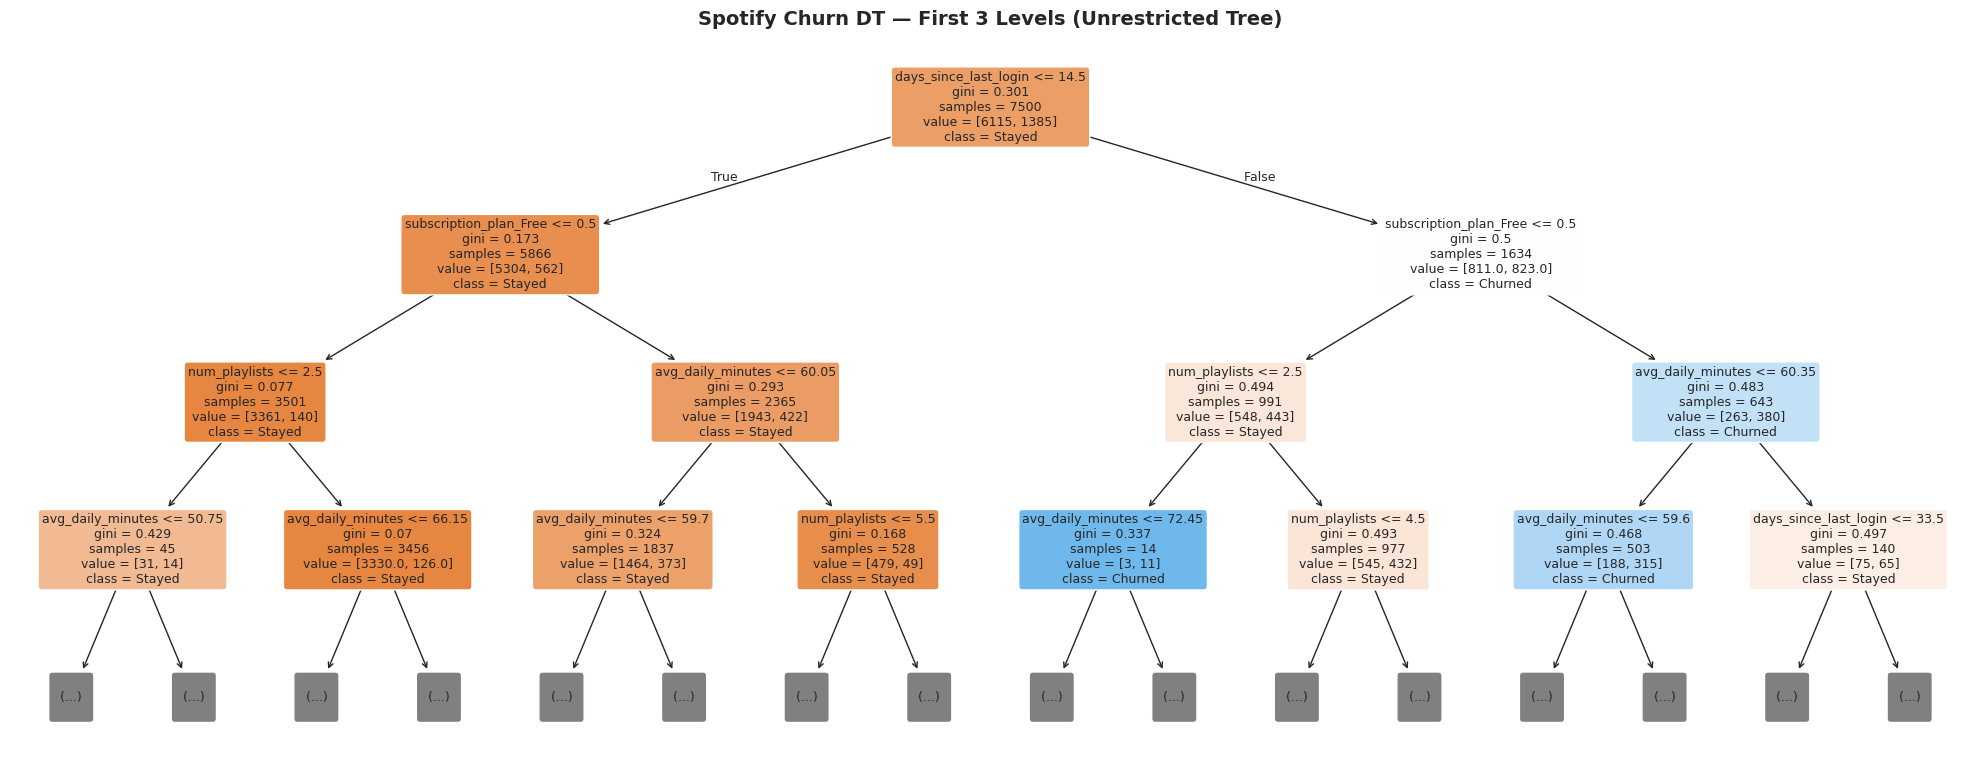


TOP RULES (text format):
|--- days_since_last_login <= 14.50
|   |--- subscription_plan_Free <= 0.50
|   |   |--- num_playlists <= 2.50
|   |   |   |--- avg_daily_minutes <= 50.75
|   |   |   |   |--- truncated branch of depth 12
|   |   |   |--- avg_daily_minutes >  50.75
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- num_playlists >  2.50
|   |   |   |--- avg_daily_minutes <= 66.15
|   |   |   |   |--- truncated branch of depth 24
|   |   |   |--- avg_daily_minutes >  66.15
|   |   |   |   |--- truncated branch of depth 10
|   |--- subscription_plan_Free >  0.50
|   |   |--- avg_daily_minutes <= 60.05
|   |   |   |--- avg_daily_minutes <= 59.70
|   |   |   |   |--- truncated branch of depth 35
|   |   |   |--- avg_daily_minutes >  59.70
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- avg_daily_minutes >  60.05
|   |   |   |--- num_playlists <= 5.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- num_playlists >  5.50
|   |   |   |   |--

In [14]:
# ============================================
# VISUALIZE THE TOP OF THE TREE
# ============================================

fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(tree_unlimited, max_depth=3, feature_names=X_train.columns,
          class_names=['Stayed', 'Churned'], filled=True, rounded=True,
          fontsize=9, ax=ax, impurity=True)
ax.set_title('Spotify Churn DT — First 3 Levels (Unrestricted Tree)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# Also show text rules
print("\nTOP RULES (text format):")
print(export_text(tree_unlimited, feature_names=list(X_train.columns), max_depth=3))


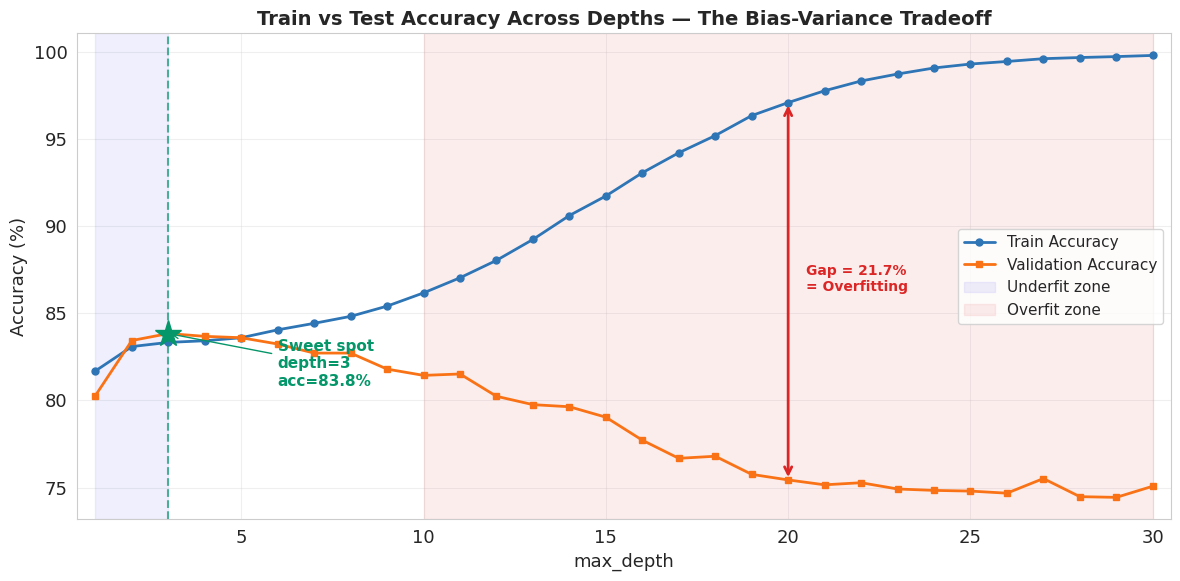


🎯 Best test accuracy: 83.8% at depth=3
   Compare: depth=30 gives train=99.8%, test=75.1%
   The gap at depth 30 = 24.7% ← OVERFIT


In [15]:
# ============================================
# DEPTH vs ACCURACY — THE OVERFITTING CURVE
# ============================================

depths = range(1, 31)
train_accs = []
test_accs = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(tree.score(X_train, y_train) * 100)
    test_accs.append(tree.score(X_test, y_test) * 100)

# Find best test accuracy
best_depth = depths[np.argmax(test_accs)]
best_test_acc = max(test_accs)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(depths, train_accs, 'o-', color='#2E75B6', linewidth=2, markersize=5, label='Train Accuracy')
ax.plot(depths, test_accs, 's-', color='#F97316', linewidth=2, markersize=5, label='Validation Accuracy')

# Highlight zones
ax.axvspan(1, 3, alpha=0.1, color='#6366F1', label='Underfit zone')
ax.axvspan(10, 30, alpha=0.08, color='#DC2626', label='Overfit zone')

# Mark sweet spot
ax.axvline(x=best_depth, color='#059669', linestyle='--', linewidth=1.5, alpha=0.7)
ax.plot(best_depth, best_test_acc, '*', color='#059669', markersize=20, zorder=5)
ax.annotate(f'Sweet spot\ndepth={best_depth}\nacc={best_test_acc:.1f}%',
            xy=(best_depth, best_test_acc), xytext=(best_depth+3, best_test_acc-3),
            fontsize=11, fontweight='bold', color='#059669',
            arrowprops=dict(arrowstyle='->', color='#059669'))

# Mark gap
mid_depth = 20
ax.annotate('', xy=(mid_depth, train_accs[mid_depth-1]), xytext=(mid_depth, test_accs[mid_depth-1]),
            arrowprops=dict(arrowstyle='<->', color='#DC2626', lw=2))
ax.text(mid_depth + 0.5, (train_accs[mid_depth-1] + test_accs[mid_depth-1])/2,
        f'Gap = {train_accs[mid_depth-1] - test_accs[mid_depth-1]:.1f}%\n= Overfitting',
        fontsize=10, color='#DC2626', fontweight='bold')

ax.set_xlabel('max_depth', fontsize=13)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Train vs Test Accuracy Across Depths — The Bias-Variance Tradeoff', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='center right')
ax.set_xlim(0.5, 30.5)
plt.tight_layout()
plt.show()

print(f"\n🎯 Best test accuracy: {best_test_acc:.1f}% at depth={best_depth}")
print(f"   Compare: depth=30 gives train={train_accs[29]:.1f}%, test={test_accs[29]:.1f}%")
print(f"   The gap at depth 30 = {train_accs[29] - test_accs[29]:.1f}% ← OVERFIT")
